# Churn Prediction: IBM Telco Customer Churn

This notebook is intentionally concise. The goal is to frame the churn decision clearly, compare a simple baseline with a stronger model, and turn model output into practical retention actions.

## Executive Summary

- The objective is to identify customers most at risk of churn so retention efforts can be focused where they are most likely to pay off.
- On this test split, Logistic Regression slightly outperformed XGBoost on ROC-AUC (`0.846` vs `0.841`), showing that the baseline is already strong.
- In a budget-constrained scenario, targeting the top 20% highest-risk customers captures about 50% of actual churners and roughly `$229k` (`56%` of annualized churn revenue in this test split).
- Contract structure is the clearest actionable lever: month-to-month customers churn about 15x as often as two-year contract customers.
- Recommended decision policy: rank customers by churn risk, select the top segment based on campaign capacity, then prioritize the highest-risk and highest-value customers for tailored offers.

Dataset: [IBM Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [56]:
from pathlib import Path
import subprocess
import zipfile

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## Problem Framing

**Business question:** Which customers are most likely to churn soon, and how should a retention team act on that signal?

**Decision framing:** This is primarily a ranking problem, not a pure classification problem. The model is used to prioritize limited retention budget toward the customers most likely to churn.

**Why it matters:** Retention is usually cheaper than acquisition. Even a moderately accurate churn model can improve campaign targeting, reduce wasted incentives, and help support teams intervene earlier.

**Target (`y`):** Whether a customer churned (`1`) or stayed (`0`).

**Business use:** The predicted output is a risk signal, not a certainty. Higher-risk customers move higher on the retention priority list, while the final action depends on budget, customer value, and campaign capacity.

**Success criteria:**
- Rank customers by churn risk reliably.
- Pick an operating threshold that matches retention capacity.
- Surface interpretable drivers so actions are not just predictive, but useful.

## Design Principle: From Metrics to Decisions

Model evaluation is not framed as prediction quality alone. It is framed as a budget-constrained targeting problem, where model scores are assessed by how well they support real campaign allocation decisions.

## Data Understanding

The dataset is a customer-level snapshot with demographics, account details, subscribed services, monthly spend, total spend, and churn outcome.

For a retention decision, the most relevant feature groups are:
- Contract and tenure: strong signals of commitment and lifecycle stage.
- Billing and payment behavior: often linked to churn friction.
- Product mix: customers with different service bundles tend to behave differently.
- Revenue variables: `MonthlyCharges` and `TotalCharges` help size the value at risk.

In [57]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
data_path = data_dir / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

if not data_path.exists():
    archive_path = data_dir / 'telco-customer-churn.zip'
    subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'blastchar/telco-customer-churn', '-p', str(data_dir)],
        check=True,
    )
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

df = pd.read_csv(data_path)
print(f'Loaded {df.shape[0]:,} rows and {df.shape[1]} columns from {data_path}')
df.head()

Loaded 7,043 rows and 21 columns from data/WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
display(df.info())

summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_values': df.isna().sum().values,
    'unique_values': df.nunique().values,
})

display(summary)
display(pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(3))
display(pd.crosstab(df['InternetService'], df['Churn'], normalize='index').round(3))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

None

,column,dtype,missing_values,unique_values
0,customerID,str,0,7043
1,gender,str,0,2
2,SeniorCitizen,int64,0,2
3,Partner,str,0,2
4,Dependents,str,0,2
5,tenure,int64,0,73
6,PhoneService,str,0,2
7,MultipleLines,str,0,3
8,InternetService,str,0,3
9,OnlineSecurity,str,0,3


Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


A few patterns stand out even before modeling. Churn is materially higher for month-to-month customers, which suggests commitment level is likely to be a major driver. Internet service mix also appears relevant, indicating that product bundle and pricing experience may influence retention risk.

A few data quality considerations are worth noting before modeling:
- `TotalCharges` is not fully numeric and contains blank values.
- Those missing values appear to be linked to very new customers, so the issue is likely structural rather than random.
- The target is imbalanced enough that accuracy would be a weak primary metric.
- Most inputs are categorical, so consistent encoding is required.
- `customerID` is an identifier and should not be used as a model feature.

## Data Preparation

The preparation steps are simple and deliberate:
- Convert `TotalCharges` to numeric because it arrives as text.
- Treat blank `TotalCharges` values as missing.
- Keep preprocessing inside sklearn pipelines to avoid train-test leakage.
- Use a `ColumnTransformer` so numeric and categorical columns can be processed differently in one reusable step.
- One-hot encode categoricals so both models can use the same feature matrix.

In [59]:
df = df.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

customer_ids = df['customerID']
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

categorical_features = [
    column for column in X.columns
    if pd.api.types.is_object_dtype(X[column]) or pd.api.types.is_string_dtype(X[column])
]
numeric_features = [column for column in X.columns if column not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',  # numeric columns need median imputation and scaling
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            'cat',  # categorical columns need most_frequent imputation and one-hot encoding
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
            ]),
            categorical_features,
        ),
    ]
)

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=0.25,  # 0.75/0.25 train-test split
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Missing values after TotalCharges conversion:')
display(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
display(df.loc[df['TotalCharges'].isna(), ['tenure', 'MonthlyCharges', 'Contract']].head())
print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Churn rate: {y.mean():.1%}")

Missing values after TotalCharges conversion:


TotalCharges    11
dtype: int64

,tenure,MonthlyCharges,Contract
488,0,52.55,Two year
753,0,20.25,Two year
936,0,80.85,Two year
1082,0,25.75,Two year
1340,0,56.05,Two year


Train rows: 5,282 | Test rows: 1,761
Churn rate: 26.5%


`TotalCharges` produces a small number of missing values after conversion because some rows contain blanks instead of numbers. In this dataset, those rows typically correspond to newer customers with limited tenure, so the missingness is expected rather than random. Keeping those customers in the analysis is more useful than dropping them, so the missing values are imputed inside the pipeline in a consistent way.

## Baseline Model (Logistic Regression)

Logistic Regression is a strong baseline for churn prediction: it is fast to train, stable, and easy to explain. That makes it a good reference point for deciding whether a more complex model creates enough extra business value to justify its added complexity.

In [60]:
log_reg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
])

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Advanced Model (XGBoost)

XGBoost is included because churn can depend on nonlinear effects and interactions, such as tenure by contract type or billing behavior by service mix.

This is intentionally light-touch tuning. The goal is to test whether a more flexible model creates meaningful lift over the baseline, not to over-optimize a small notebook example.

In [61]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=2,
            subsample=0.9,
            colsample_bytree=0.8,
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=RANDOM_STATE,
        ),
    ),
])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Model Evaluation

This is not just a classification task. In practice, the model is used to rank customers by churn risk so the business can focus limited retention resources where they are most likely to matter.

Evaluation compares the model signal with what actually happened:
- **Actual `y`:** whether the customer truly churned (`1`) or stayed (`0`).
- **Predicted probability:** the model's estimated churn risk.
- **Predicted `y`:** the final churn flag after applying a threshold to that probability.

Two evaluation views are useful here:
- **Ranking view:** Does the model place the riskiest customers near the top of the list?
- **Decision view:** If the business acts on the model, what outreach trade-offs follow?

Evaluation should reflect both ranking quality and campaign usefulness:
- **ROC-AUC:** How well the predicted probabilities rank actual churners above non-churners across thresholds.
- **Precision:** Of the customers predicted as churners, how many actually churned.
- **Recall:** Of the customers who actually churned, how many were correctly predicted as churners.
- **F1:** A compact balance between precision and recall.
- **Confusion matrix:** Shows the counts behind those outcomes, including missed churners and unnecessary outreach.

,model,roc_auc,precision,recall,f1
0,Logistic Regression,0.846,0.518,0.794,0.627
1,XGBoost,0.841,0.664,0.507,0.575


Selected model for operational examples: Logistic Regression


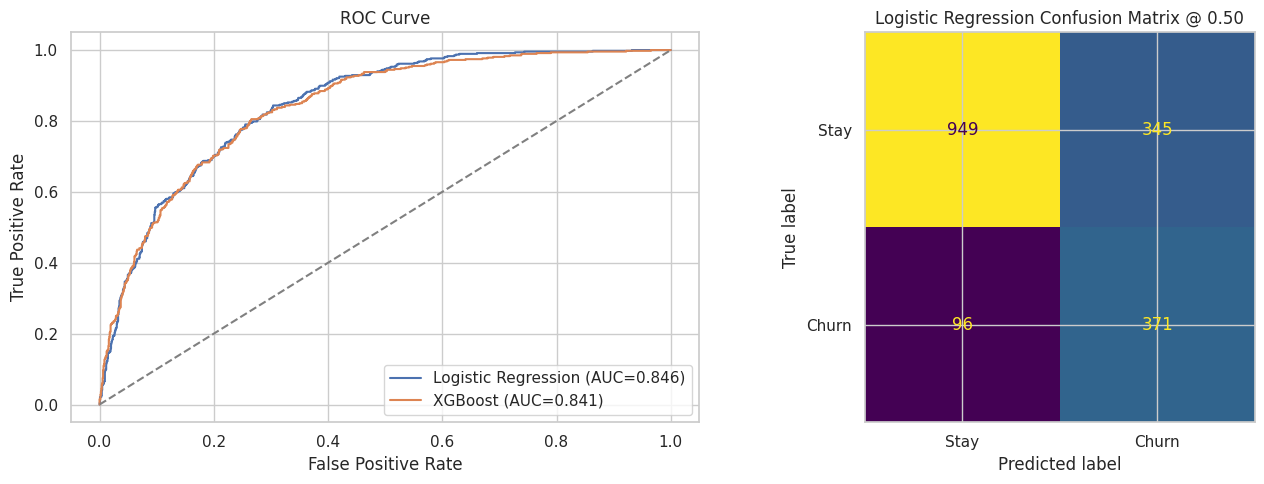

In [62]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        preds,
        average='binary',
        zero_division=0,
    )
    return {
        'roc_auc': roc_auc_score(y_test, proba),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': preds,
        'probabilities': proba,
    }


log_reg_results = evaluate_model(log_reg_model, X_test, y_test)
xgb_results = evaluate_model(xgb_model, X_test, y_test)

candidate_results = {
    'Logistic Regression': log_reg_results,
    'XGBoost': xgb_results,
}
selected_model_name = max(candidate_results, key=lambda name: candidate_results[name]['roc_auc'])
selected_results = candidate_results[selected_model_name]

metrics_table = pd.DataFrame([
    {
        'model': 'Logistic Regression',
        'roc_auc': log_reg_results['roc_auc'],
        'precision': log_reg_results['precision'],
        'recall': log_reg_results['recall'],
        'f1': log_reg_results['f1'],
    },
    {
        'model': 'XGBoost',
        'roc_auc': xgb_results['roc_auc'],
        'precision': xgb_results['precision'],
        'recall': xgb_results['recall'],
        'f1': xgb_results['f1'],
    },
]).round(3)

display(metrics_table)
print(f'Selected model for operational examples: {selected_model_name}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, results in [('Logistic Regression', log_reg_results), ('XGBoost', xgb_results)]:
    fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={results['roc_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

cm = confusion_matrix(y_test, selected_results['predictions'])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'{selected_model_name} Confusion Matrix @ 0.50')

plt.tight_layout()
plt.show()

The ROC curves answer the ranking question: which model is better at pushing likely churners toward the top of the list? On this split, the baseline is slightly better, which is why it becomes the selected model for the operational examples.

The confusion matrix answers a different question: what happens if the business uses a simple yes/no rule? With the default `0.50` threshold, the model correctly flags `371` churners, misses `96`, and would send unnecessary outreach to `345` customers who were predicted to churn but actually stayed.

## Top-K Campaign Policy Evaluation

Retention teams often work from a ranked list rather than a fixed probability cutoff. Top-K evaluation asks how many actual churners are captured when the business contacts only the top 10%, 20%, or 30% highest-risk customers.

The key distinction between the next two sections is simple: Top-K assumes the business already knows how large the campaign should be, while threshold-based policy assumes the business wants a yes/no rule based on model probability.

This is different from threshold tuning:
- **Threshold tuning** asks which probability cutoff should turn the same model scores into a yes/no action rule.
- **Top-K evaluation** asks what happens when the business simply takes the highest-risk slice of customers, regardless of the exact cutoff value.

That makes Top-K the more operational view when campaign size is fixed.

,model,top_pct,customers_targeted,churners_captured_pct,precision_within_segment
0,Logistic Regression,10,177,0.283,0.746
1,Logistic Regression,20,353,0.505,0.669
2,Logistic Regression,30,529,0.666,0.588
3,XGBoost,10,177,0.276,0.729
4,XGBoost,20,353,0.501,0.663
5,XGBoost,30,529,0.666,0.588


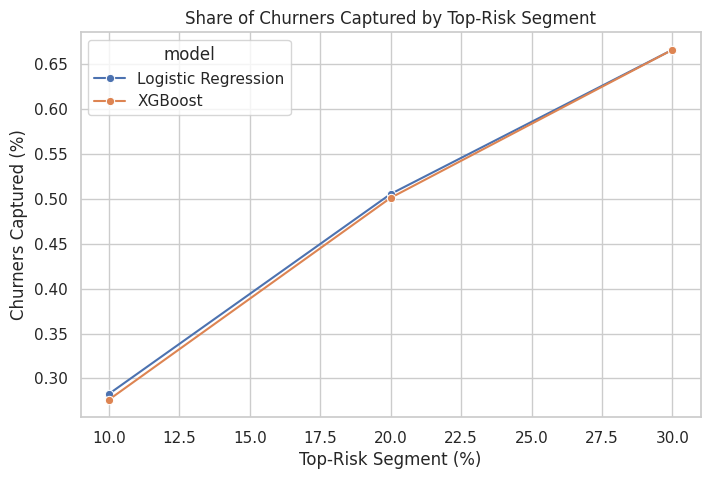

In [63]:
def top_k_metrics(y_true, probabilities, top_pct):
    n_customers = int(np.ceil(len(y_true) * top_pct))
    top_index = np.argsort(probabilities)[::-1][:n_customers]
    captured_churners = y_true.iloc[top_index].sum()
    return {
        'top_pct': int(top_pct * 100),
        'customers_targeted': n_customers,
        'churners_captured_pct': captured_churners / y_true.sum(),
        'precision_within_segment': y_true.iloc[top_index].mean(),
    }


top_k_rows = []
for model_name, results in candidate_results.items():
    for top_pct in [0.10, 0.20, 0.30]:
        row = top_k_metrics(y_test.reset_index(drop=True), pd.Series(results['probabilities']), top_pct)
        row['model'] = model_name
        top_k_rows.append(row)

top_k_table = pd.DataFrame(top_k_rows)[[
    'model',
    'top_pct',
    'customers_targeted',
    'churners_captured_pct',
    'precision_within_segment',
]]

display(top_k_table.round(3))

sns.lineplot(data=top_k_table, x='top_pct', y='churners_captured_pct', hue='model', marker='o')
plt.title('Share of Churners Captured by Top-Risk Segment')
plt.xlabel('Top-Risk Segment (%)')
plt.ylabel('Churners Captured (%)')
plt.show()

Top-K Targeting (Budget-Constrained Scenario):
- Target the top 10% highest-risk customers: captures about 28% of churners.
- Target the top 20% highest-risk customers: captures about 50% of churners.

This enables prioritized retention intervention when budget or outreach capacity is limited.

## Threshold Policy Sensitivity Analysis

The default `0.50` threshold is rarely the best business choice.

This section can be read as a sensitivity analysis of one specific policy: flag any customer whose predicted churn probability is above a chosen cutoff.

A `0.50` threshold means any customer with predicted churn probability of 50% or more is labeled as a likely churner. Changing that threshold changes the action rule applied to the same model output; it does not change the underlying model or the predicted probabilities themselves. It is a standard modeling default, but it is not automatically the best rule for a retention campaign.

For retention teams:
- Lower threshold: reach more potential churners, but spend more budget on customers who may have stayed anyway.
- Higher threshold: concentrate budget on fewer customers, but allow more likely churners to go untouched.

A good operating point depends on campaign cost, agent capacity, and the value of saving a customer. This threshold view is still useful because some workflows need a yes/no action rule, but many retention teams will prefer the Top-K view when campaign size is fixed.

`predict_proba` is used here instead of hard class labels so the action rule can be adjusted without retraining the model.

,threshold,precision,recall,f1,targeted_customers
0,0.20,0.390,0.961,0.555,1150
1,0.25,0.408,0.940,0.569,1075
2,0.30,0.433,0.927,0.590,1001
3,0.35,0.450,0.906,0.602,939
4,0.40,0.471,0.865,0.610,857
5,0.45,0.498,0.844,0.626,791
6,0.50,0.518,0.794,0.627,716
7,0.55,0.535,0.758,0.627,662
8,0.60,0.553,0.717,0.624,606
9,0.65,0.579,0.675,0.623,544


Recommended threshold based on max F1 on the test set: 0.50


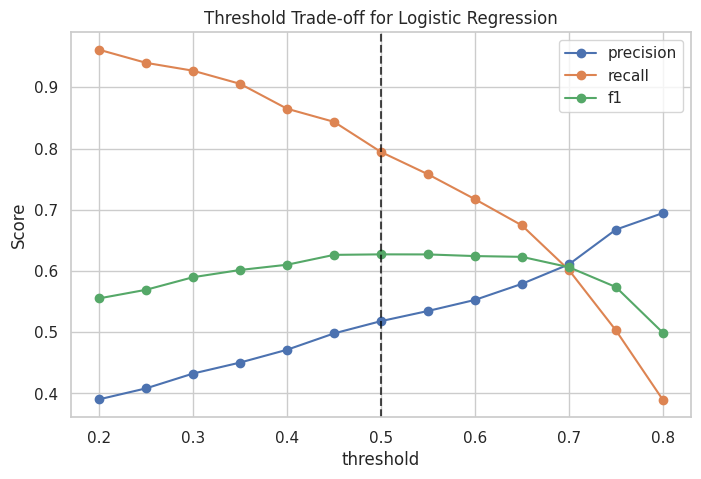

In [64]:
thresholds = np.arange(0.2, 0.81, 0.05)
threshold_rows = []

for threshold in thresholds:
    preds = (selected_results['probabilities'] >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        preds,
        average='binary',
        zero_division=0,
    )
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'targeted_customers': int(preds.sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)
recommended_threshold = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']

display(threshold_df.round(3))
print(f'Recommended threshold based on max F1 on the test set: {recommended_threshold:.2f}')

ax = threshold_df.plot(x='threshold', y=['precision', 'recall', 'f1'], marker='o')
ax.axvline(recommended_threshold, linestyle='--', color='black', alpha=0.7)
ax.set_title(f'Threshold Trade-off for {selected_model_name}')
ax.set_ylabel('Score')
plt.show()

This plot makes the campaign trade-off visible. Lower thresholds capture more at-risk customers but expand campaign volume. In that sense, it is a sensitivity analysis of the policy cutoff: it shows how the results change when the yes/no action rule becomes more or less aggressive. This is most useful when the business wants a yes/no action rule; Top-K is usually the clearer view when the business already knows how many customers it can contact.

## Feature Importance

Once the model is shown to be useful for ranking customers and supporting policy decisions, the next question is feature interpretation: *which features are most associated with churn risk, and which of those features can inform action?* Because Logistic Regression is the selected model for the operational examples on this split, the feature view below uses Logistic Regression coefficients.

The focus here is on directional interpretation rather than claiming pure causality.

,feature,coefficient
16,cat__InternetService_Fiber optic,0.679
36,cat__Contract_Month-to-month,0.638
3,num__TotalCharges,0.501
35,cat__StreamingMovies_Yes,0.283
32,cat__StreamingTV_Yes,0.239
43,cat__PaymentMethod_Electronic check,0.209
18,cat__OnlineSecurity_No,0.207
27,cat__TechSupport_No,0.175


,feature,coefficient
1,num__tenure,-1.144
38,cat__Contract_Two year,-0.735
2,num__MonthlyCharges,-0.655
15,cat__InternetService_DSL,-0.599
39,cat__PaperlessBilling_No,-0.281
22,cat__OnlineBackup_No internet service,-0.270
25,cat__DeviceProtection_No internet service,-0.270
28,cat__TechSupport_No internet service,-0.270


,churn_rate,vs_two_year
Contract,,
Month-to-month,0.427,15.08
One year,0.113,3.98
Two year,0.028,1.00


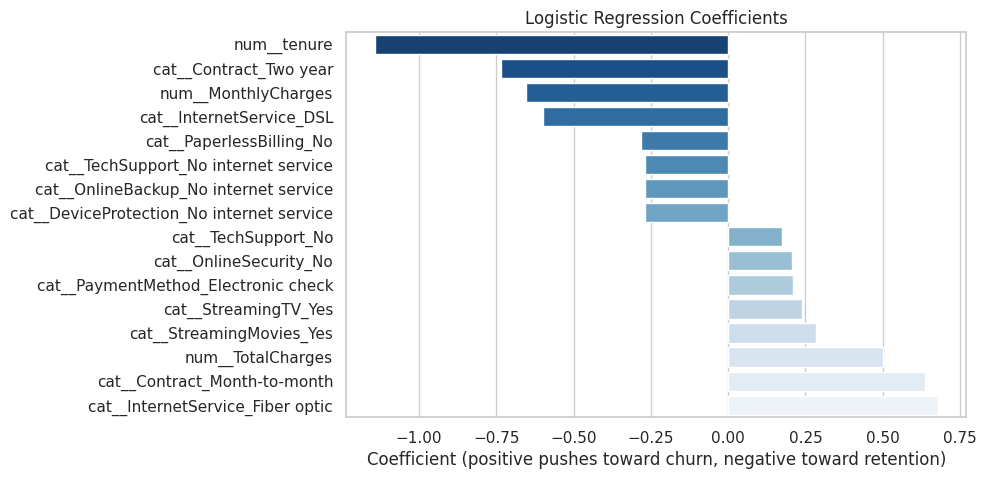

In [65]:
feature_names = log_reg_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = log_reg_model.named_steps['model'].coef_[0]

coefficient_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
top_positive_features = coefficient_df.sort_values('coefficient', ascending=False).head(8)
top_negative_features = coefficient_df.sort_values('coefficient', ascending=True).head(8)

display(top_positive_features[['feature', 'coefficient']].round(3))
display(top_negative_features[['feature', 'coefficient']].round(3))

importance_df = (
    pd.concat([
        top_positive_features[['feature', 'coefficient']],
        top_negative_features[['feature', 'coefficient']],
    ])
    .drop_duplicates('feature')
    .sort_values('coefficient')
)

contract_churn = (
    df.groupby('Contract')['Churn']
    .mean()
    .sort_values(ascending=False)
    .rename('churn_rate')
    .to_frame()
)
contract_churn['vs_two_year'] = (contract_churn['churn_rate'] / contract_churn.loc['Two year', 'churn_rate']).round(2)
display(contract_churn.round(3))

sns.barplot(data=importance_df, x='coefficient', y='feature', hue='feature', dodge=False, palette='Blues_r', legend=False)
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient (positive pushes toward churn, negative toward retention)')
plt.ylabel('')
plt.show()

The Logistic Regression coefficients give a directional interpretation of risk: positive coefficients push the prediction toward churn, while negative coefficients are associated with retention. The pattern is consistent with the business lens used throughout the notebook: weaker commitment, shorter tenure, and billing-related friction are strong risk signals. The contract-rate comparison makes that pattern concrete: month-to-month customers churn at roughly 15x the rate of two-year customers, making contract structure the strongest actionable lever in this dataset. These patterns are useful for targeting and message design, but they should not be treated as causal proof.

## Business Insights

The main business patterns in this dataset are intuitive:
- Short-tenure customers are more fragile because commitment is still low.
- Month-to-month contracts are a strong signal of low lock-in, and the observed churn rate is about 15x the rate for two-year contracts.
- Billing friction and higher monthly charges are common churn correlates.
- Customers with lighter service bundles can be easier to lose.

The retention team should use the model as a prioritization layer, not as a standalone decision-maker.

In [66]:
scored_test = X_test.copy()
scored_test['customerID'] = id_test.values
scored_test['actual_churn'] = y_test.values
scored_test['churn_probability'] = selected_results['probabilities']
scored_test['predicted_churn'] = (scored_test['churn_probability'] >= recommended_threshold).astype(int)

high_risk_customers = scored_test.sort_values('churn_probability', ascending=False).head(10)
display(
    high_risk_customers[
        [
            'customerID',
            'tenure',
            'Contract',
            'MonthlyCharges',
            'PaymentMethod',
            'InternetService',
            'churn_probability',
            'actual_churn',
        ]
    ].round({'MonthlyCharges': 2, 'churn_probability': 3})
)

segment_summary = (
    scored_test.assign(risk_band=pd.qcut(scored_test['churn_probability'], q=5, duplicates='drop'))
    .groupby('risk_band')
    .agg(
        customers=('customerID', 'count'),
        avg_churn_probability=('churn_probability', 'mean'),
        actual_churn_rate=('actual_churn', 'mean'),
        avg_monthly_charges=('MonthlyCharges', 'mean'),
    )
    .round(3)
)

display(segment_summary)

assumed_save_rate = 0.20
top20_n = int(np.ceil(len(scored_test) * 0.20))
top20_segment = scored_test.sort_values('churn_probability', ascending=False).head(top20_n)
annual_revenue_at_risk = (top20_segment.loc[top20_segment['actual_churn'] == 1, 'MonthlyCharges'] * 12).sum()
total_annual_churn_revenue = (scored_test.loc[scored_test['actual_churn'] == 1, 'MonthlyCharges'] * 12).sum()
impact_summary = pd.DataFrame([
    {
        'model_used': selected_model_name,
        'campaign_size_pct': 20,
        'customers_targeted': top20_n,
        'actual_churners_reached_pct': top20_segment['actual_churn'].sum() / scored_test['actual_churn'].sum(),
        'annualized_churn_revenue_captured_pct': annual_revenue_at_risk / total_annual_churn_revenue,
        'annualized_revenue_at_risk_in_segment': annual_revenue_at_risk,
        'illustrative_saved_revenue_at_20pct_save_rate': annual_revenue_at_risk * assumed_save_rate,
    }
]).round(3)

display(impact_summary)

,customerID,tenure,Contract,MonthlyCharges,PaymentMethod,InternetService,churn_probability,actual_churn
3380,5178-LMXOP,1,Month-to-month,95.10,Electronic check,Fiber optic,0.936,1
4585,1069-XAIEM,1,Month-to-month,85.05,Electronic check,Fiber optic,0.924,1
3346,2545-EBUPK,2,Month-to-month,84.05,Electronic check,Fiber optic,0.924,0
2631,6861-XWTWQ,7,Month-to-month,99.25,Electronic check,Fiber optic,0.924,1
6866,0295-PPHDO,1,Month-to-month,95.45,Electronic check,Fiber optic,0.924,1
6365,8884-ADFVN,7,Month-to-month,101.95,Electronic check,Fiber optic,0.920,1
933,4750-ZRXIU,4,Month-to-month,84.60,Electronic check,Fiber optic,0.919,1
3727,9057-SIHCH,3,Month-to-month,96.60,Electronic check,Fiber optic,0.917,1
4517,2012-NWRPA,11,Month-to-month,99.55,Electronic check,Fiber optic,0.916,1
6894,1400-MMYXY,3,Month-to-month,105.90,Electronic check,Fiber optic,0.916,1


,customers,avg_churn_probability,actual_churn_rate,avg_monthly_charges
risk_band,,,,
"(0.00479, 0.0845]",353,0.036,0.008,43.758
"(0.0845, 0.263]",352,0.162,0.074,64.162
"(0.263, 0.51]",352,0.387,0.196,60.157
"(0.51, 0.75]",352,0.649,0.381,73.060
"(0.75, 0.936]",352,0.834,0.668,81.306


,model_used,campaign_size_pct,customers_targeted,actual_churners_reached_pct,annualized_churn_revenue_captured_pct,annualized_revenue_at_risk_in_segment,illustrative_saved_revenue_at_20pct_save_rate
0,Logistic Regression,20,353,0.505,0.555,228573.6,45714.72


Practical retention actions from this output:
- Route the highest-risk customers to a save campaign first instead of spreading budget across the full customer base.
- Match the offer to the likely driver: contract flexibility, billing support, or service bundling.
- Prioritize high-risk, high-value customers when capacity is limited.
- Track lift by intervention type so the model improves business decisions, not just model metrics.

Illustrative business lens: if a retained customer is worth about `$500` annually, even a modest improvement in retention within the top-risk segment can translate into meaningful protected revenue.

## Decision Policy

A practical decision policy for this use case is:
1. Rank customers by predicted churn probability.
2. Select the top segment based on campaign capacity.
3. Within that segment, prioritize high-risk and high-value customers.
4. Match the intervention to the likely churn driver, such as contract flexibility, billing support, or service bundling.

## Limitations and Scope

This notebook is intentionally scoped to prediction and prioritization rather than full decision optimization.
- The model estimates churn risk, but it does not identify the causal reason a customer leaves.
- No intervention or offer-response data is available, so the notebook cannot estimate which retention action is most effective for each customer.
- Threshold selection is illustrated from a precision-recall perspective, not optimized using full retention economics such as customer lifetime value, offer cost, or contact cost.
- A simple train-test split and light tuning are used by design to keep the analysis concise and readable.

## Optional: Production Considerations

If this were moving beyond a notebook, the next steps would be:
- Save the full preprocessing + model pipeline as one artifact.
- Score customers on a fixed cadence and store probabilities for campaign tooling.
- Monitor data drift, such as shifts in customer mix, contract mix, or pricing patterns.
- Retrain periodically, for example monthly or quarterly, depending on how quickly the business changes.
- Monitor feature drift, churn rate drift, and threshold performance over time.
- Close the loop with campaign outcomes so the model can be evaluated on retention impact, not only predictive accuracy.

## References

Metric definitions follow standard scikit-learn conventions for binary classification.
- Model evaluation guide: https://scikit-learn.org/stable/modules/model_evaluation.html
- ROC-AUC: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
- Precision / Recall / F1: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html
- Confusion matrix: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html